# Predictions per model

In [4]:
import sys
sys.path.append('../src')

import re
import ast
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from Config.config import PATHS
from Utils.utils import GetMeasurements
from Utils.interaction import Performer
from Utils.indices import AlternationIndex
from Classes.cognitive_model_agents import (
    PayoffM2, AttendanceM2, FocalRegionAgent, FRAplus
)

### Parameter sweeps

In [1]:
fixed_parameters = {
    'num_agents':3,
    'threshold':0.7
}
simulation_parameters = {
    'num_rounds': 100,
    'num_episodes': 30,
    'verbose': False
}
df_list = []
for learning_rate in [0.1, 0.2, 0.5]:
    free_parameters = {
        'inverse_temperature': 16,
        'learning_rate': learning_rate,
    }
    df = Performer.sim(
        agent_class=PayoffM2,
        fixed_parameters=fixed_parameters,
        free_parameters=free_parameters,
        simulation_parameters=simulation_parameters,
    )
    df['learning_rate'] = learning_rate
    df_list.append(df)
df = pd.concat(df_list, ignore_index=True)

NameError: name 'Performer' is not defined

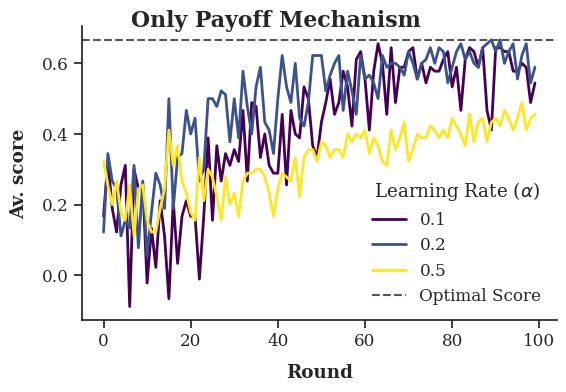

In [ ]:
# 1. Set the academic style and font scale
sns.set_theme(style="ticks", font_scale=1.1)
plt.rcParams["font.family"] = "serif"  # Standard for academic papers (e.g., Times New Roman)

# 2. Initialize the plot with standard journal dimensions
fig, ax = plt.subplots(figsize=(6, 4))

# 3. Create the line plot with a professional palette
# 'rocket_r' or 'viridis' look much more academic than default bright colors
sns.lineplot(
    x='round', 
    y='score', 
    hue='learning_rate',
    palette='viridis', 
    linewidth=2,
    errorbar=None, 
    data=df,
    ax=ax
)

# 4. Draw the horizontal baseline (muted color, labeled)
ax.axhline(
    y=2/3, 
    color='#555555',       # Muted dark grey instead of harsh red
    linestyle='--', 
    linewidth=1.5,
    label='Optimal Score'  # Added label for the legend
)

# 5. Clean up labels and presentation
ax.set_xlabel('Round', fontweight='bold', labelpad=10)
ax.set_ylabel('Av. score', fontweight='bold', labelpad=10)

# De-clutter the legend and place it cleanly
ax.legend(title=r'Learning Rate ($\alpha$)', frameon=True, facecolor='white', edgecolor='none')

# 6. Final professional touches
sns.despine()            # Removes the top and right spines
plt.tight_layout()       # Ensures nothing gets cut off

fig.suptitle('Only Payoff Mechanism', fontweight='bold')

plt.show()

In [2]:
fixed_parameters = {
    'num_agents':3,
    'threshold':0.7
}
simulation_parameters = {
    'num_rounds': 100,
    'num_episodes': 10,
    'verbose': False
}
df_list = []
for bias in [0, 0.2, 0.4, 0.6, 0.8, 1.0]:
    for forget in [0, 0.2, 0.4, 0.6, 0.8, 1.0]:
        free_parameters = {
            'inverse_temperature': 16,
            'learning_rate': 0.1,
            'bias': bias,
            'forget': forget
        }
        df1 = Performer.sim(
            agent_class=AttendanceM2,
            fixed_parameters=fixed_parameters,
            free_parameters=free_parameters,
            simulation_parameters=simulation_parameters,
        )
        df1['bias'] = bias
        df1['forget'] = forget
        df_list.append(df1)
df1 = pd.concat(df_list, ignore_index=True)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

...

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

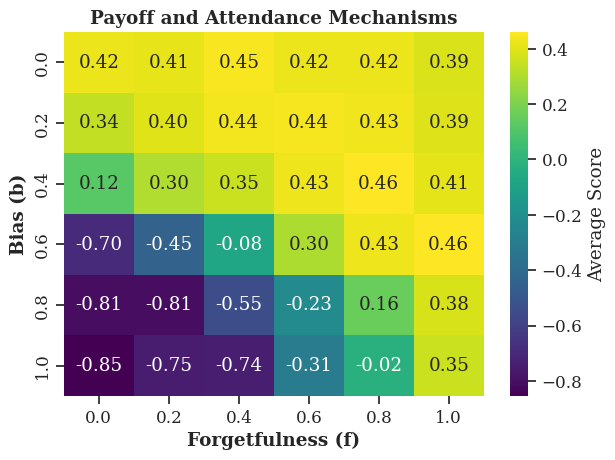

In [ ]:
sns.heatmap(
    data=df1.pivot_table(index='bias', columns='forget', values='score'),
    annot=True, fmt=".2f", cmap='viridis', cbar_kws={'label': 'Average Score'}
)
plt.xlabel('Forgetfulness (f)', fontweight='bold')
plt.ylabel('Bias (b)', fontweight='bold')
plt.title('Payoff and Attendance Mechanisms', fontweight='bold')
plt.tight_layout()
plt.show()

In [29]:
agent = FocalRegionAgent(
    free_parameters=free_parameters,
    fixed_parameters=fixed_parameters
)
for pattern in agent.sfr.focal_regions:
    print(pattern)

------------------------------------------------------------
[[0. 1.]
 [1. 0.]]
------------------------------------------------------------


In [22]:
free_parameters = {
    'inverse_temperature': 16,
    'learning_rate': 0.1,
    'bias': 0.4,
    'forget': 0.8,
    'len_history': 2,
    'delta': 0.5,
}
fixed_parameters = {
    'num_agents':2,
    'threshold':0.7
}
for c in [0.8, 0.85, 0.9, 0.95, 1.0]:
    for inverse_temperature in [4, 8, 16]:
        free_parameters = {
            'inverse_temperature': inverse_temperature,
            'len_history': 2,
            'c': c
        }
        df3 = Performer.sim(
            agent_class=FocalRegionAgent,
            fixed_parameters=fixed_parameters,
            free_parameters=free_parameters,
            simulation_parameters=simulation_parameters,
        )
        df3['c'] = c
        df3['inverse_temperature'] = inverse_temperature
        df_list.append(df3)
df3 = pd.concat(df_list, ignore_index=True)

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

...

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

  0%|          | 0/1 [00:00<?, ?it/s]

In [38]:
free_parameters = {
    'inverse_temperature': 0,
    'len_history': 2,
    'c': 0.9
}
simulation_parameters = {
    'num_rounds': 30,
    'num_episodes': 1,
    'verbose': False
}
df = Performer.sim(
    agent_class=FocalRegionAgent,
    fixed_parameters=fixed_parameters,
    free_parameters=free_parameters,
    simulation_parameters=simulation_parameters
)

  0%|          | 0/1 [00:00<?, ?it/s]

<Axes: >

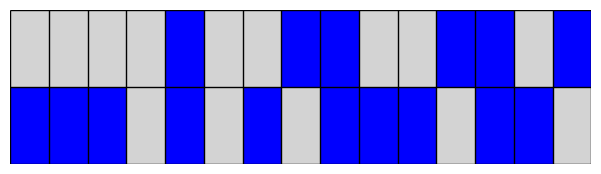

In [39]:
from Classes.bar import Bar

bar = Bar.from_pandas(df)
bar.render()

<Axes: xlabel='round', ylabel='score'>

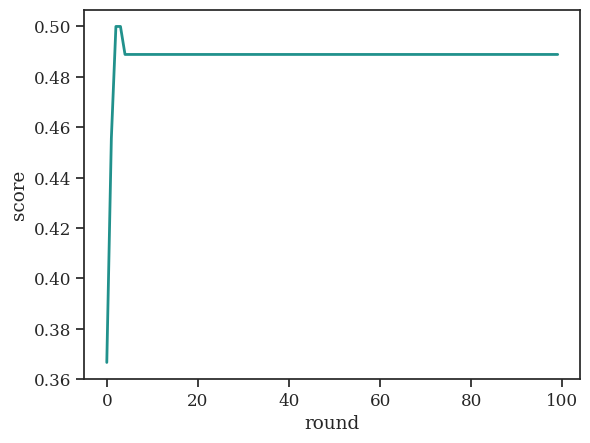

In [ ]:
mask = (df3['c'] ==0.8) & (df3['inverse_temperature'] == 16)
sns.lineplot(
    x='round', 
    y='score', 
    hue='model',
    palette='viridis', 
    linewidth=2,
    errorbar=None, 
    data=df3[mask],
)

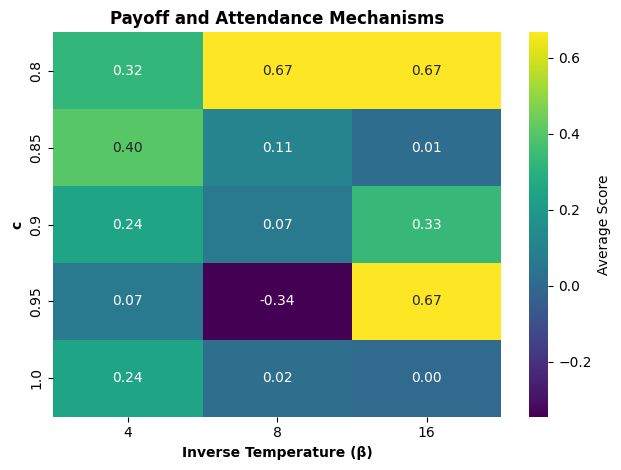

In [14]:
sns.heatmap(
    data=df3.pivot_table(index='c', columns='inverse_temperature', values='score'),
    annot=True, fmt=".2f", cmap='viridis', cbar_kws={'label': 'Average Score'}
)
plt.xlabel('Inverse Temperature (β)', fontweight='bold')
plt.ylabel('c', fontweight='bold')
plt.title('Payoff and Attendance Mechanisms', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
free_parameters = {
    'inverse_temperature': 16,
    'learning_rate': 0.1,
    'bias': 0.4,
    'forget': 0.8,
}
fixed_parameters = {
    'num_agents':3,
    'threshold':0.7
}
simulation_parameters = {
    'num_rounds': 100,
    'num_episodes': 10,
    'verbose': False
}
df_list = []
for model_class in [PayoffM2, AttendanceM2]:
    df2 = Performer.sim(
        agent_class=model_class,
        fixed_parameters=fixed_parameters,
        free_parameters=free_parameters,
        simulation_parameters=simulation_parameters,
    )
    df2['model'] = model_class.name()
    df_list.append(df2)
df2 = pd.concat(df_list, ignore_index=True)

  0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/10 [00:00<?, ?it/s]

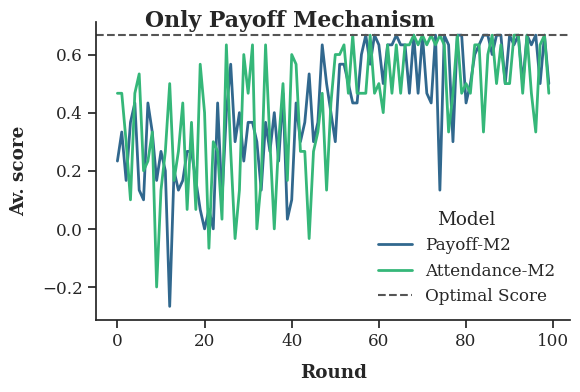

In [ ]:
# 2. Initialize the plot with standard journal dimensions
fig, ax = plt.subplots(figsize=(6, 4))

# 3. Create the line plot with a professional palette
# 'rocket_r' or 'viridis' look much more academic than default bright colors
sns.lineplot(
    x='round', 
    y='score', 
    hue='model',
    palette='viridis', 
    linewidth=2,
    errorbar=None, 
    data=df2,
    ax=ax
)

# 4. Draw the horizontal baseline (muted color, labeled)
ax.axhline(
    y=2/3, 
    color='#555555',       # Muted dark grey instead of harsh red
    linestyle='--', 
    linewidth=1.5,
    label='Optimal Score'  # Added label for the legend
)

# 5. Clean up labels and presentation
ax.set_xlabel('Round', fontweight='bold', labelpad=10)
ax.set_ylabel('Av. score', fontweight='bold', labelpad=10)

# De-clutter the legend and place it cleanly
ax.legend(title=r'Model', frameon=True, facecolor='white', edgecolor='none')

# 6. Final professional touches
sns.despine()            # Removes the top and right spines
plt.tight_layout()       # Ensures nothing gets cut off

fig.suptitle('Only Payoff Mechanism', fontweight='bold')

plt.show()

In [ ]:
path_to_data = PATHS['simulated_data'] / 'optimal_parameters.csv'
optimal_parameters = pd.read_csv(path_to_data)

In [ ]:
def parse_params(s):
    if not isinstance(s, str):
        return s
    # Replace np.float64(x) and np.int64(x) with x
    s = re.sub(r'np\.float64\(([^)]+)\)', r'\1', s)
    s = re.sub(r'np\.int64\(([^)]+)\)', r'\1', s)
    return ast.literal_eval(s)

In [ ]:
MODEL_BY_NAME = {m.name(): m for m in [PayoffM2, AttendanceM2, FRAplus]}

fixed_parameters = {
    'num_agents': 2,
    'threshold': 0.5,
}
simulation_parameters = {
    'num_rounds': 10,
    'num_episodes': 10,
    'verbose': False
}

df_list =[] 
for idx, row in optimal_parameters.iterrows():
    if row['model'] not in MODEL_BY_NAME:
        continue
    model_class = MODEL_BY_NAME[row['model']]
    free_parameters = parse_params(row['params'])
    df = Performer.sim(
        agent_class=model_class,
        fixed_parameters=fixed_parameters,
        free_parameters=free_parameters,
        simulation_parameters=simulation_parameters
    )
    df_list.append(df)

df = pd.concat(df_list, ignore_index=True)
df.head(2)


  0%|          | 0/10 [00:00<?, ?it/s]

/Users/edgar/Documents/GitHub/Cognitive_Models_El_Farol_Bar_Problem/Notebooks/../src/Utils/interaction.py:920: SyntaxWarning: invalid escape sequence '\m'
  'x_label':'$\mu$',


KeyError: 'forget'

In [ ]:
gm = GetMeasurements(
    data=df, 
    measures=[
        'efficiency', 'inequality',
        'bounded_efficiency', 
        'entropy', 'conditional_entropy', 
        'conditional_entropy_2nd_order', 'min_entropy'
    ],
    normalize=True,
)
data = gm.get_measurements()
index_gen = AlternationIndex.from_file(priority='mlp')
data['inequality'] = index_gen(data)
data.head(2)

Exception: Error: No column data found. Should be one of "id_sim", "room", or "group".
Columns found: Index(['round', 'attendance', 'id_player', 'decision', 'score'], dtype='str')